# EO-SAR Change Detection — Kaggle Training Notebook

**Task**: Binary semantic segmentation for multimodal change detection  
**Input**: Pre-event EO (RGB) + Post-event SAR (grayscale) → 4-channel tensor  
**Model**: UNet++ with EfficientNet-B3 encoder  
**Output**: Per-pixel change mask (0 = no change, 1 = change)

This notebook is a **launcher** — all implementation lives in the project modules.  
It installs dependencies, configures paths, and calls `train.py` / `eval.py`.

## 1. Environment Check

In [1]:
import torch

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version    : {torch.version.cuda}")
    print(f"GPU Device      : {torch.cuda.get_device_name(0)}")
    print(f"GPU Count       : {torch.cuda.device_count()}")
else:
    print("Running on CPU")

PyTorch Version : 2.10.0+cu128
CUDA Available  : True
CUDA Version    : 12.8
GPU Device      : Tesla T4
GPU Count       : 2


## 2. Install Dependencies

In [2]:
!pip install -q segmentation-models-pytorch==0.3.3 \
                timm==0.9.2 \
                albumentations==1.3.1 \
                tifffile==2024.2.12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 16.4 MB/s eta 0:00:00


In [3]:
import torch
import segmentation_models_pytorch as smp
import albumentations
import tifffile
import timm

print("All imports successful")
print(torch.cuda.get_device_name(0))

All imports successful
Tesla T4


## 3. Configure Dataset Paths

On Kaggle, datasets are mounted under `/kaggle/input/`.  
Update `DATA_ROOT` to the folder containing `train/`, `val/`, and `test/`.

In [7]:
import torch, shutil, os, sys, importlib.util

# =========================
# PATHS
# =========================
BASE        = "/kaggle/input/datasets/gauravsingh101/galaxy-code"
DATA_ROOT   = "/kaggle/input/datasets/gauravsingh101/galaxyeye/Galaxy Data"
PROJECT_DIR = "/kaggle/working/Galaxy-AI"

# =========================
# CLEAN OLD WORKING DIR
# =========================
if os.path.exists(PROJECT_DIR):
    shutil.rmtree(PROJECT_DIR)

os.makedirs(PROJECT_DIR, exist_ok=True)

# =========================
# COPY PROJECT FILES
# =========================
for item in os.listdir(BASE):
    s = os.path.join(BASE, item)
    d = os.path.join(PROJECT_DIR, item)

    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("✅ Files copied")
print(os.listdir(PROJECT_DIR))

os.chdir(PROJECT_DIR)

# =========================
# DYNAMIC MODULE LOADER
# =========================
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

dataset_mod = load_module(
    "datasets.dataset",
    os.path.join(PROJECT_DIR, "Galaxy AI", "datasets", "dataset.py")
)

model_mod = load_module(
    "models.model",
    os.path.join(PROJECT_DIR, "Galaxy AI", "models", "model.py")
)

EOSARDataset   = dataset_mod.EOSARDataset
get_transforms = dataset_mod.get_transforms
build_model    = model_mod.build_model

print("✅ Modules loaded")

✅ Files copied
['Galaxy AI']
✅ Modules loaded


## 4. Sanity Check — Dataloader & Model

In [32]:
import yaml
import torch
from datasets.dataset import EOSARDataset, get_transforms

# Load config
with open("/kaggle/working/Galaxy-AI/Galaxy AI/configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

# Build dataset and grab one sample
_, val_tf = get_transforms(cfg)
ds = EOSARDataset(cfg["data"]["root_dir"], "train", cfg["data"]["image_size"], val_tf)
img, mask, fname = ds[0]

print(f"Image shape : {img.shape}   range=[{img.min():.3f}, {img.max():.3f}]")
print(f"Mask shape  : {mask.shape}  unique={mask.unique().tolist()}")
print(f"File        : {fname}")

/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/transforms.py:184: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


[train] 2781 samples  →  /kaggle/input/datasets/gauravsingh101/galaxyeye/Galaxy Data/train/pre-event
Image shape : torch.Size([4, 512, 512])   range=[0.000, 0.894]
Mask shape  : torch.Size([1, 512, 512])  unique=[0.0, 1.0]
File        : scene_01_000001_building_damage.tif


## 5. Visualise a Sample Batch

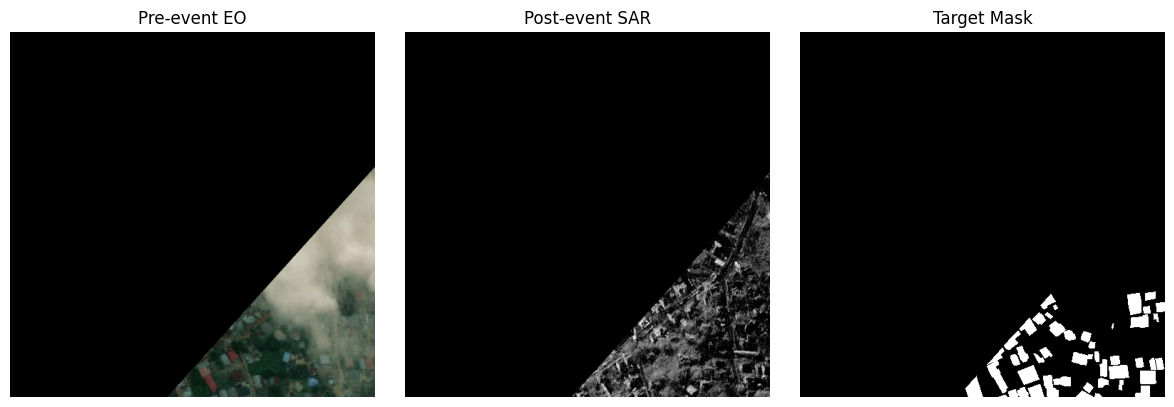

Preview saved: sample_preview.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img[:3].permute(1,2,0).numpy())       # EO RGB
axes[1].imshow(img[3].numpy(), cmap='gray')           # SAR
axes[2].imshow(mask[0].numpy(), cmap='binary_r')      # target
for ax, t in zip(axes, ['Pre-event EO', 'Post-event SAR', 'Target Mask']):
    ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.savefig('sample_preview.png', dpi=100, bbox_inches='tight')
plt.show()
print('Preview saved: sample_preview.png')

## 7. Full Training

In [51]:
!python train.py --config configs/config.yaml --name kaggle_run_v1

2026-05-14 12:07:17.242886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778760437.266068   20779 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778760437.274058   20779 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778760437.294580   20779 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778760437.294615   20779 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778760437.294619   20779 computation_placer.cc:177] computation placer alr

## 8. Resume Training (if interrupted)

In [ ]:
# Find latest checkpoint
import glob
checkpoints = sorted(glob.glob('experiments/*/checkpoints/latest.pth'))
if checkpoints:
    latest = checkpoints[-1]
    print(f'Resuming from: {latest}')
    !python train.py --config configs/config.yaml --resume "{latest}"
else:
    print('No checkpoint found — run full training first.')

## 9. Evaluate on Validation Set

In [54]:
import os, glob

# Code lives here (eval.py, configs/)
CODE_DIR = "/kaggle/working/Galaxy-AI/Galaxy AI"
os.chdir(CODE_DIR)

# Experiments were saved here (one level up — matches config experiment_dir)
CKPT_DIR = "/kaggle/working/Galaxy-AI/experiments"

best   = f"{CKPT_DIR}/kaggle_run_v1/checkpoints/best.pth"
config = f"{CODE_DIR}/configs/config.yaml"

if os.path.exists(best):
    !python -u eval.py --config "{config}" \
                       --checkpoint "{best}" \
                       --split val \
                       --n-vis 8
else:
    print(f"Not found: {best}")
    found = glob.glob(f"{CKPT_DIR}/*/checkpoints/best.pth")
    print("Available:", found if found else "none")

2026-05-14 14:39:50.105985: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778769590.130825  143892 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778769590.138937  143892 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778769590.159225  143892 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778769590.159253  143892 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778769590.159257  143892 computation_placer.cc:177] computation placer alr

## 10. Final Evaluation on Test Set

> **Only run this once** — after all hyperparameter tuning is complete.  
> Using the test set for model selection constitutes data leakage.

In [71]:
import yaml

CONFIG = "/kaggle/working/Galaxy-AI/Galaxy AI/configs/config.yaml"

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)

cfg["metrics"]["threshold"] = 0.94
cfg["model"]["encoder"] = "efficientnet-b3"

with open(CONFIG, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

# Verify
with open(CONFIG) as f:
    check = yaml.safe_load(f)
print("threshold :", check["metrics"]["threshold"])
print("encoder   :", check["model"]["encoder"])

threshold : 0.94
encoder   : efficientnet-b3


In [72]:
CKPT   = "/kaggle/working/Galaxy-AI/experiments/kaggle_run_v1/checkpoints/best.pth"
CONFIG = "/kaggle/working/Galaxy-AI/Galaxy AI/configs/config.yaml"
!python -u eval.py --config "{CONFIG}" --checkpoint "{CKPT}" --split test --n-vis 16

2026-05-14 15:30:30.818080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778772630.842279  146486 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778772630.850069  146486 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778772630.870372  146486 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778772630.870400  146486 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778772630.870404  146486 computation_placer.cc:177] computation placer alr

## 11. Visualise Predictions

In [ ]:
from IPython.display import Image, display
import glob

# Show prediction grids from the latest eval run
pred_imgs = sorted(glob.glob('experiments/*/eval_test/predictions/predictions.png'))
if pred_imgs:
    display(Image(pred_imgs[-1]))

error_imgs = sorted(glob.glob('experiments/*/eval_test/error_analysis/error_analysis.png'))
if error_imgs:
    display(Image(error_imgs[-1]))

## 12. TensorBoard

Load training curves inline.

In [59]:
%load_ext tensorboard
%tensorboard --logdir experiments

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 144440), started 0:00:00 ago. (Use '!kill 144440' to kill it.)

<IPython.core.display.Javascript object>